<a href="https://colab.research.google.com/github/PoudelUtsav7/Customer-Behaviour-Analysis_Python_SQL_Dashboard/blob/main/1_LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **LeNet-5 on FashionMNIST (Pytorch)**

A from scratch PyTorch Implementation of LeNet-5 trained and evaluated on FashionMNIST

- 28 * 28 grayscale images are handled with passing=2 in teh first conv, which matches the original 32 * 32 geometry
- Tanh activations and average pooling
- The original RBF output layer is replaced by a plain Linear layer trained with CrossEntropyLoss

In [74]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Data

In [75]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("\nTrain: ", len(train_dataset))
print("Test: ", len(test_dataset))
print("Image shape:", train_dataset[0][0].shape)


Train:  60000
Test:  10000
Image shape: torch.Size([1, 28, 28])


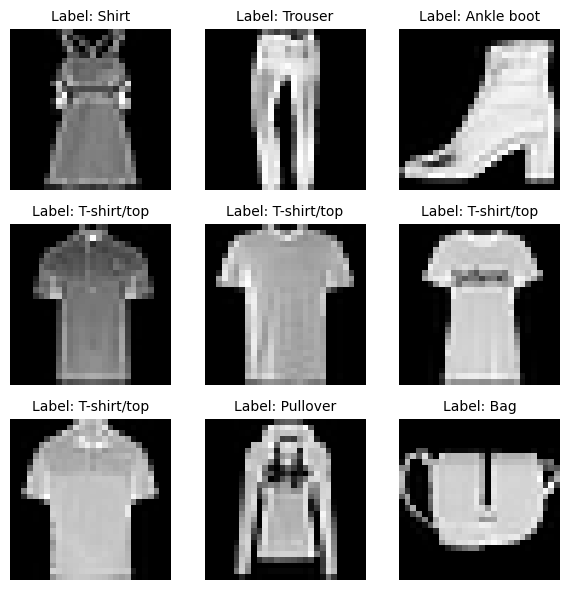

In [76]:
# Create a 3x3 grid for displaying images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i in range(9): # Iterate 9 times for a 3x3 grid
  idx = random.randint(0, len(train_dataset) - 1)
  image_tensor, label = train_dataset[idx]

  to_pil = transforms.ToPILImage()
  image = to_pil(image_tensor)

  ax = axes[i] # Get the current subplot axis
  ax.imshow(image, cmap='gray') # Use 'gray' colormap for grayscale images
  ax.set_title(f"Label: {train_dataset.classes[label]}", fontsize=10) # Display the class name as title
  ax.axis('off') # Turn off axis for a cleaner image display

plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show()

In [77]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [65]:
# next(iter(train_dataloader))

In [66]:
# batch_features, batch_labels = next(iter(train_dataloader))
# print(batch_features)
# print(batch_labels)
# print('_'*50)

## Model


```
Input 28×28×1
  → Conv 5×5, 1→6,  padding=2 + Tanh   → 28×28×6    (C1)
  → AvgPool 2×2                        → 14×14×6    (S2)
  → Conv 5×5, 6→16 + Tanh              → 10×10×16   (C3)
  → AvgPool 2×2                        → 5×5×16     (S4)
  → Conv 5×5, 16→120 + Tanh            → 1×1×120    (C5)
  → Flatten                            → 120
  → Linear 120→84 + Tanh               → 84         (F6)
  → Linear 84→10                       → 10 logits  (output)
```

In [67]:
import torch
import torch.nn as nn

class LeNET(nn.Module):
  def __init__(self,
               in_channels=1,
               num_classes=10):

    super().__init__()

    # Feature Extraction
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, #C1: 28*28*6
                  out_channels=6,
                  kernel_size=5,
                  stride=1,
                  padding=2),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2),      #S2: 14*14*6

        nn.Conv2d(in_channels=6,          #C3: 10*10*16
                  out_channels=16,
                  kernel_size=5,
                  stride=1,
                  padding=0),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2),     #S4: 5*5*16

        nn.Conv2d(in_channels=16,
                  out_channels=120,
                  kernel_size=5,
                  stride=1,
                  padding=0)            #C5: 1*1*120
    )

    # Classification
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(120, 84),
        nn.Tanh(),
        nn.Linear(84, num_classes)
    )

  def forward(self, x):
        return self.classifier(self.features(x))

In [69]:
# Create model for grayscale images
model = LeNET(in_channels=1, num_classes=10).to(device)
print(model)

# Test different image sizes
# for size in [28, 32, 64, 128]:

#     x = torch.randn(8, 1, size, size)

#     output = model(x)

#     print(f"Input: {x.shape} -> Output: {output.shape}")

LeNET(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [70]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training and Testing `LeNET`

In [71]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [72]:
import torch
import torch.nn as nn


def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
  train_loss = 0
  train_acc = 0

  model.to(device)
  model.train()

  for X, y in data_loader:
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y)

    train_loss += loss.item()

    # 3. Calculate accuracy
    y_pred_class = y_pred.argmax(dim=1)

    train_acc += ((y_pred_class == y).sum().item())

    # 4. Zero gradients
    optimizer.zero_grad()

    # 5. Backpropagation
    loss.backward()

    # 6. Update weights
    optimizer.step()

  # Average loss across batches
  train_loss /= len(data_loader)

  # Accuracy across all samples
  train_acc /= len(data_loader.dataset)

  return train_loss, train_acc

In [73]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              device: torch.device):

  test_loss = 0
  test_acc = 0

  model.to(device)
  model.eval()

  with torch.inference_mode():

    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculate loss
      test_loss += loss_fn(test_pred,y).item()

      # 3. Calculate accuracy
      test_pred_class = test_pred.argmax(dim=1)
      test_acc += ((test_pred_class == y).sum().item())

  # Average loss
  test_loss /= len(data_loader)

  # Accuracy
  test_acc /= len(data_loader.dataset)

  return test_loss, test_acc


In [51]:
train_losses = []
test_losses = []

train_accs = []
test_accs = []

epochs = 20

for epoch in range(epochs):

    train_loss, train_acc = train_step(model=model,
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)


    test_loss, test_acc = test_step(model=model,
                                    data_loader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)


    # Save history
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch: {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc * 100:.2f}%"
    )

Epoch: 1/20 | Train Loss: 0.5758 | Train Acc: 78.81% | Test Loss: 0.4683 | Test Acc: 83.08%
Epoch: 2/20 | Train Loss: 0.4147 | Train Acc: 84.85% | Test Loss: 0.4178 | Test Acc: 84.57%
Epoch: 3/20 | Train Loss: 0.3742 | Train Acc: 86.34% | Test Loss: 0.3972 | Test Acc: 85.33%
Epoch: 4/20 | Train Loss: 0.3552 | Train Acc: 86.94% | Test Loss: 0.3847 | Test Acc: 86.09%
Epoch: 5/20 | Train Loss: 0.3396 | Train Acc: 87.63% | Test Loss: 0.3744 | Test Acc: 86.55%
Epoch: 6/20 | Train Loss: 0.3294 | Train Acc: 87.86% | Test Loss: 0.3686 | Test Acc: 86.51%
Epoch: 7/20 | Train Loss: 0.3220 | Train Acc: 88.18% | Test Loss: 0.3567 | Test Acc: 86.89%
Epoch: 8/20 | Train Loss: 0.3132 | Train Acc: 88.50% | Test Loss: 0.3578 | Test Acc: 86.83%
Epoch: 9/20 | Train Loss: 0.3090 | Train Acc: 88.56% | Test Loss: 0.3668 | Test Acc: 86.41%
Epoch: 10/20 | Train Loss: 0.3010 | Train Acc: 89.04% | Test Loss: 0.3454 | Test Acc: 87.81%
Epoch: 11/20 | Train Loss: 0.3008 | Train Acc: 88.89% | Test Loss: 0.3408 | Tes

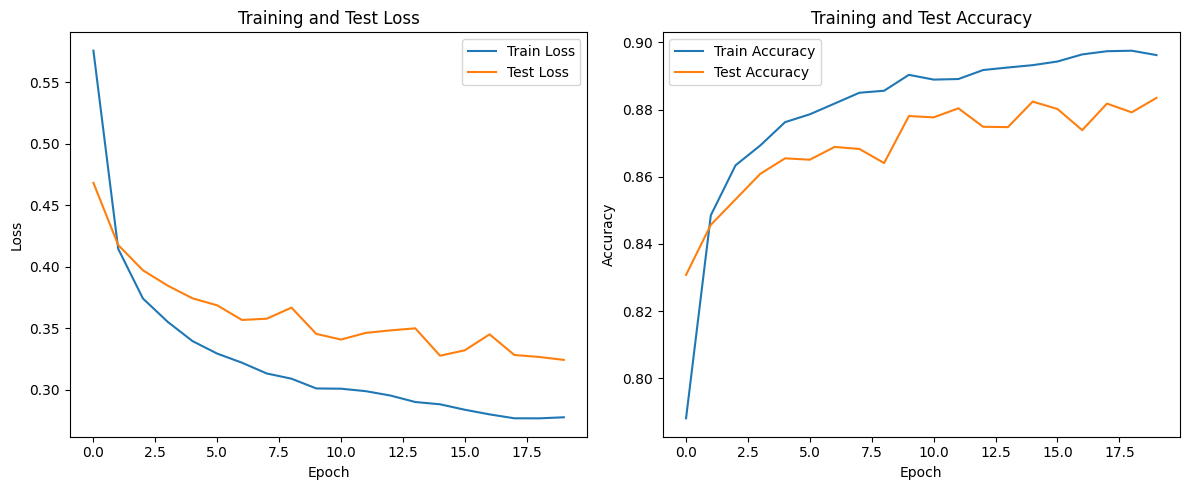

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()


# Accuracy
plt.subplot(1, 2, 2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.title("Training and Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

In [53]:
image, label = test_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", test_dataset.classes[label])

Image shape: torch.Size([1, 28, 28])
Label: 9
Class: Ankle boot


In [54]:
image, label = test_dataset[0]
print("Before:", image.shape)

image = image.unsqueeze(0)
print("After:", image.shape)

Before: torch.Size([1, 28, 28])
After: torch.Size([1, 1, 28, 28])


## Evaluation

In [55]:
model.eval()

with torch.inference_mode():
    prediction = model(image.to(device))

predicted_class = prediction.argmax(dim=1).item()

print("Predicted class index:", predicted_class)
print("Actual class index:", label)

print("Predicted:",test_dataset.classes[predicted_class])

print("Actual:",test_dataset.classes[label])

Predicted class index: 9
Actual class index: 9
Predicted: Ankle boot
Actual: Ankle boot


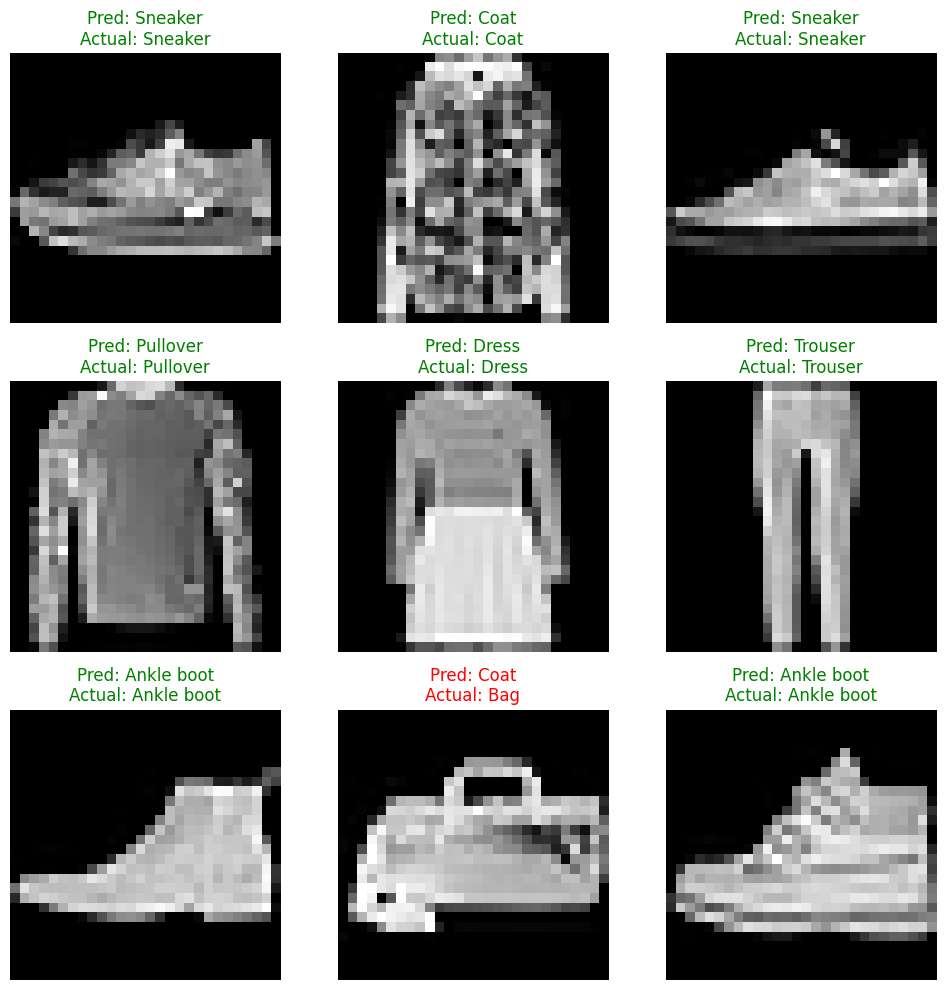

In [56]:
import matplotlib.pyplot as plt

model.eval()
fig, axes = plt.subplots(3,3,figsize=(10, 10))

axes = axes.flatten()
for i in range(9):
    # Pick random image
    idx = torch.randint(0,len(test_dataset),(1,)).item()
    image, label = test_dataset[idx]

    # Add batch dimension
    image_batch = image.unsqueeze(0).to(device)

    # Prediction
    with torch.inference_mode():
        prediction = model(image_batch)

    predicted_class = prediction.argmax(dim=1).item()

    # Display image
    axes[i].imshow(image.squeeze(),cmap="gray")

    # Get class names
    predicted_name = test_dataset.classes[predicted_class]
    actual_name = test_dataset.classes[label]

    # Green if correct, red if incorrect
    color = "green" if predicted_class == label else "red"

    axes[i].set_title(
        f"Pred: {predicted_name}\n"
        f"Actual: {actual_name}",
        color=color
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Whats model got wrong

In [57]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.inference_mode():

    for X, y in test_dataloader:

        X = X.to(device)
        y = y.to(device)

        predictions = model(X)

        predicted_classes = predictions.argmax(dim=1)

        wrong = predicted_classes != y

        wrong_images.extend(
            X[wrong].cpu()
        )

        wrong_labels.extend(
            y[wrong].cpu()
        )

        wrong_predictions.extend(
            predicted_classes[wrong].cpu()
        )

        # Stop after collecting 20 mistakes
        if len(wrong_images) >= 20:
            break

In [58]:
print("Wrong predictions:", len(wrong_images))

Wrong predictions: 20


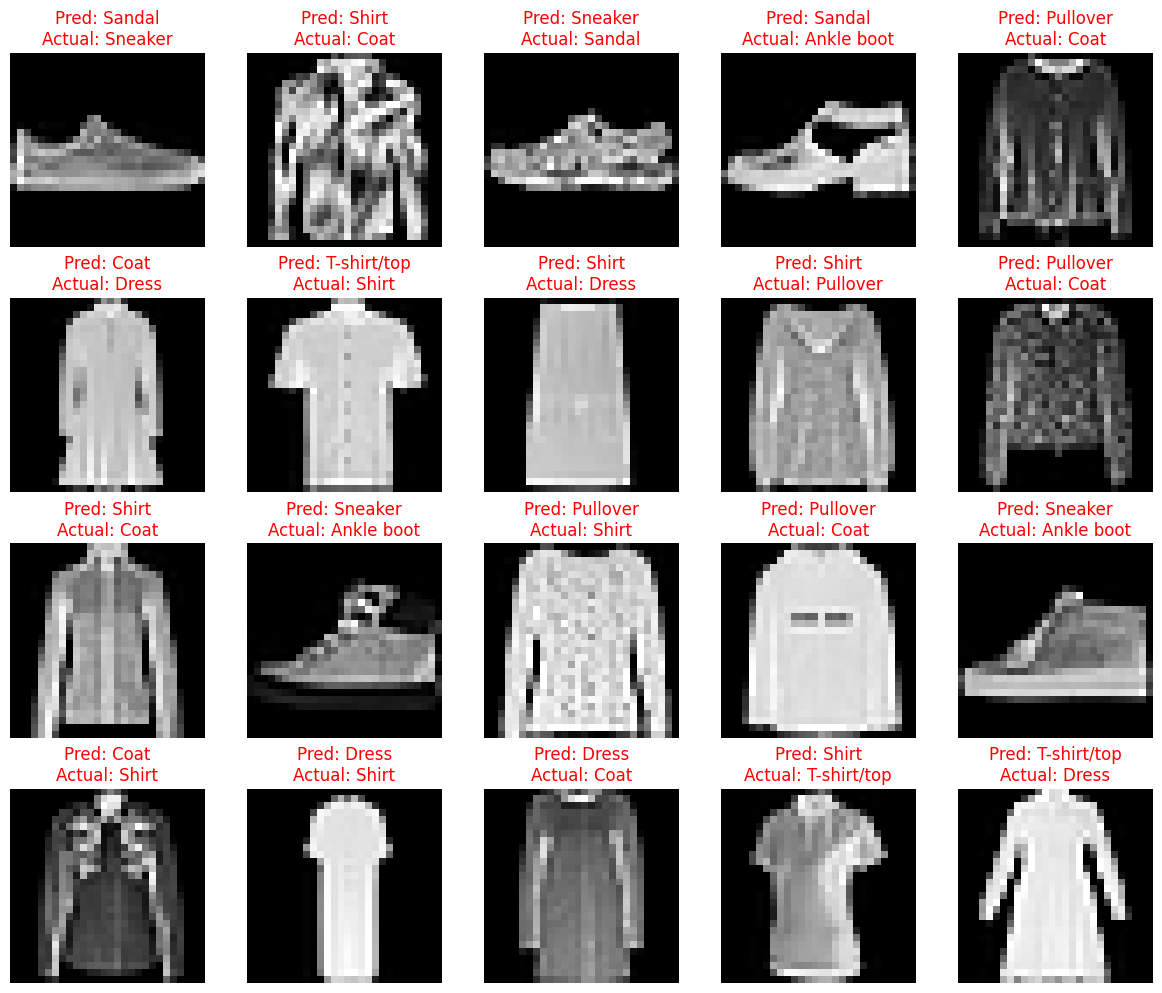

In [59]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 10)
)

axes = axes.flatten()

for i in range(min(20, len(wrong_images))):

    image = wrong_images[i]
    actual = wrong_labels[i].item()
    predicted = wrong_predictions[i].item()

    axes[i].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[i].set_title(
        f"Pred: {test_dataset.classes[predicted]}\n"
        f"Actual: {test_dataset.classes[actual]}",
        color="red"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()